In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

torch.set_default_dtype(torch.float64)
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# 0.1. Physical Parameters
E = 2e11
NU = 0.3
a = 2.0
b = 2.0
h = 0.01

Dm = (E*h)/(1-NU**2)
Db = (E*h**3)/(12*(1-NU**2))

# Manufactured Solutions
w_max = 1.0 * h

# Non-dimensionalization
w0 = h
u0 = w0**2 / a
v0 = w0**2 / b

# BCs: Choose from {'loosely clamped', 'simply supported', 'rigidly clamped'}
condition = 'loosely clamped'

# Hyperparameters
N_points = 55
epochs_Adam = 1000
epochs_LBFGS = 500

# Some arrays
previous_loss = float('inf')
loss_history = []


In [3]:
# 0.2. Manufactured Functions
def grad(f, v):
    return torch.autograd.grad(f, v, grad_outputs=torch.ones_like(f), create_graph=True)[0]

def manufactured_w(x, y):
    if 'clamped' in condition:
        # CLAMPED
        return w_max * (torch.cos(np.pi * x / a)**2) * (torch.cos(np.pi * y / b)**2)
    else:
        # SIMPLY SUPPORTED
        return w_max * torch.cos(np.pi * x / a) * torch.cos(np.pi * y / b)

def calculate_manufactured_load(x, y):
    x.requires_grad_(True)
    y.requires_grad_(True)
    
    w = manufactured_w(x, y)
    
    dw_dx = grad(w, x)
    dw_dy = grad(w, y)
    d2w_dx2 = grad(dw_dx, x)
    d2w_dy2 = grad(dw_dy, y)
    
    d3w_dx3 = grad(d2w_dx2, x)
    d4w_dx4 = grad(d3w_dx3, x)
    d3w_dy3 = grad(d2w_dy2, y)
    d4w_dy4 = grad(d3w_dy3, y)
    d3w_dx2dy = grad(d2w_dx2, y)
    d4w_dx2dy2 = grad(d3w_dx2dy, y)
    
    nabla4_w = d4w_dx4 + 2 * d4w_dx2dy2 + d4w_dy4
    
    q = Db * nabla4_w
    return q, w

In [4]:
# 0.3. Forward PINN Architecture
class EnergyPINN(nn.Module):
    def __init__(self, input_size, output_size, hidden_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, output_size)
        )
        
    def forward(self, x, y):
        # Mask cos(np.pi*x/a)**2 -> choose x/a for synthesis
        # Normalized domain [-0.5, 0.5]^2
        x_norm = x/a
        y_norm = y/b
        output = self.network(
            torch.cat([x_norm, y_norm], dim=1))
        w_norm = output[:, 0:1]
        u_norm = output[:, 1:2]
        v_norm = output[:, 2:3]

        if 'clamped' in condition:
            w_mask = (torch.cos(np.pi*x/a)**2) * (torch.cos(np.pi*y/b)**2)
        else: # SIMPLY SUPPORTED
            w_mask = torch.cos(np.pi*x/a) * torch.cos(np.pi*y/b)

        if 'rigidly' in condition:
            u_mask = x_norm * torch.cos(np.pi*x/a) * torch.cos(np.pi*y/b)
            v_mask = y_norm * torch.cos(np.pi*x/a) * torch.cos(np.pi*y/b)
        else: # LOOSELY:
            u_mask = x_norm
            v_mask = y_norm
        
        w = w_mask * w_norm * w0
        u = u_mask * u_norm * u0
        v = v_mask * v_norm * v0

        return w, u, v

In [5]:
# 0.4. Deep Energy Loss Function
def nonlinear_rectangular_plate(model, x, y, q_required):
    # Enable gradient tracking
    x.requires_grad_(True)
    y.requires_grad_(True)
    
    # Forward pass
    w, u, v = model(x, y)
    
    # Derivatives
    u_x = grad(u, x)
    u_y = grad(u, y)
    v_x = grad(v, x)
    v_y = grad(v, y)
    w_x = grad(w, x)
    w_y = grad(w, y)
    w_xx = grad(w_x, x)
    w_yy = grad(w_y, y)
    w_xy = grad(w_x, y)

    # Nonlinear Strains (von Karman)
    exx = u_x + 0.5 * (w_x**2)
    eyy = v_y + 0.5 * (w_y**2)
    exy = 0.5 * (u_y + v_x + w_x*w_y)

    # Bending Strains
    kxx = -w_xx
    kyy = -w_yy
    kxy = -w_xy

    # Strain Energy Density
    U_mem = 0.5 * Dm * (exx**2 + eyy**2 + 2*NU*exx*eyy + 2*(1-NU)*exy**2)
    U_ben = 0.5 * Db * (kxx**2 + kyy**2 + 2*NU*kxx*kyy + 2*(1-NU)*kxy**2)
    
    # External Work
    W_ext = q_required * w

    # Total energy
    Pi = torch.mean(U_mem + U_ben - W_ext) * (a*b)
    
    # Scales the energy based on the peak magnitude of the applied load
    q_max = torch.clamp(torch.max(torch.abs(q_required)), min=1.0)
    Pi0 = q_max * h * (a*b)

    return Pi/Pi0

In [6]:
# 1. Inverse Process: Method of Manufactured Solutions (MMS)
# Create a 2D grid of points
x_vals = torch.linspace(-a/2, a/2, N_points)
y_vals = torch.linspace(-b/2, b/2, N_points)
X_grid, Y_grid = torch.meshgrid(x_vals, y_vals, indexing='ij')
x_flat = X_grid.reshape(-1, 1)
y_flat = Y_grid.reshape(-1, 1)

# Calculate the required load
# print("Running Inverse Method (MMS) Calculations...")
q_required, w_prescribed = calculate_manufactured_load(x_flat, y_flat)

# Detach and reshape back to 2D for plotting
Q_required = q_required.detach().numpy().reshape(N_points, N_points)
W_prescribed = w_prescribed.detach().numpy().reshape(N_points, N_points)
X_np = X_grid.numpy()
Y_np = Y_grid.numpy()

# print(f"Maximum calculated prescribed w: {np.max(W_prescribed):.2e} m")
# print(f"Minimum calculated prescribed w: {np.min(W_prescribed):.2e} m")
# print(f"Maximum calculated required q: {np.max(Q_required):.2e} Pa")
# print(f"Minimum calculated required q: {np.min(Q_required):.2e} Pa")


In [ ]:
# 2. Forward Process: Training PINN
model = EnergyPINN(2, 3, 64)

# Training Loop
print("Training PINN...")

# --- PHASE 1: ADAM OPTIMIZER ---
optimizer_adam = optim.Adam(model.parameters(), lr=2e-3)
print("Phase 1: Adam Optimizer (Finding the neighborhood)")
for A_epoch in range(epochs_Adam+1):
    optimizer_adam.zero_grad()
    loss = nonlinear_rectangular_plate(model, x_flat, y_flat, q_required.detach())
    loss.backward()
    optimizer_adam.step()

    current_loss = loss.item()
    loss_history.append(current_loss)

    if A_epoch % 500 == 0:
        print(f"Epoch {A_epoch:<10} | Loss: {current_loss:.4e}")
    
    if A_epoch > 0:
        relative_error = abs(previous_loss - current_loss) / abs(current_loss + 1e-15)
        if relative_error < 1e-20:
            print(f"Convergent at epoch {A_epoch}. Relative error: {(relative_error):4e}")
            break
    
    previous_loss = current_loss
final_loss = nonlinear_rectangular_plate(model, x_flat, y_flat, q_required.detach())
print(f"{'Final Adam Loss:':<24} {(final_loss.item()):.4e}\n")
Adam_epoch_len = len(loss_history)

# --- PHASE 2: L-BFGS OPTIMIZER ---
print("Phase 2: L-BFGS Optimizer (High-precision polishing)")
# L-BFGS requires a static set of points during its line search closure
optimizer_lbfgs = optim.LBFGS(model.parameters(), 
                                max_iter=(epochs_LBFGS+1),
                                tolerance_grad=1e-9, 
                                tolerance_change=1e-11, 
                                history_size=100,
                                line_search_fn="strong_wolfe")

L_epoch = 0
def closure():
    global L_epoch
    optimizer_lbfgs.zero_grad()
    loss = nonlinear_rectangular_plate(model, x_flat, y_flat, q_required.detach())
    loss.backward()
    
    current_loss = loss.item()
    loss_history.append(current_loss)

    L_epoch += 1
    if L_epoch % 200 == 0:
        # print(f"L-BFGS Eval  {lbfgs_iter:04d} | Loss: {loss.item():.4e}")
        print(f"Epoch {L_epoch:<10} | Loss: {current_loss:.4e}")
    return loss
    
optimizer_lbfgs.step(closure)

# Print final loss after L-BFGS
final_loss = nonlinear_rectangular_plate(model, x_flat, y_flat, q_required.detach())
print(f"{'Final L-BFGS Loss:':<24} {(final_loss.item()):.4e}\n")

Training PINN...
Phase 1: Adam Optimizer (Finding the neighborhood)
Epoch 0          | Loss: 2.4207e-03


In [ ]:
# 3.1. Verifying
w_pred, u_pred, v_pred = model(x_flat, y_flat)

W_PRED = w_pred.detach().numpy().reshape(N_points, N_points)
W_TRUE = w_prescribed.detach().numpy().reshape(N_points, N_points)

max_true = np.max(W_TRUE)
max_pred = np.max(W_PRED)
error_percent = abs(max_pred - max_true) / max_true * 100

print(f"Target Max Deflection:       {max_true:.4e} m")
print(f"PINN Predicted Deflection:   {max_pred:.4e} m")
print(f"Absolute Verification Error: {error_percent:.2f} %")

Target Max Deflection:       1.1000e-02 m
PINN Predicted Deflection:   1.4024e-02 m
Absolute Verification Error: 27.49 %


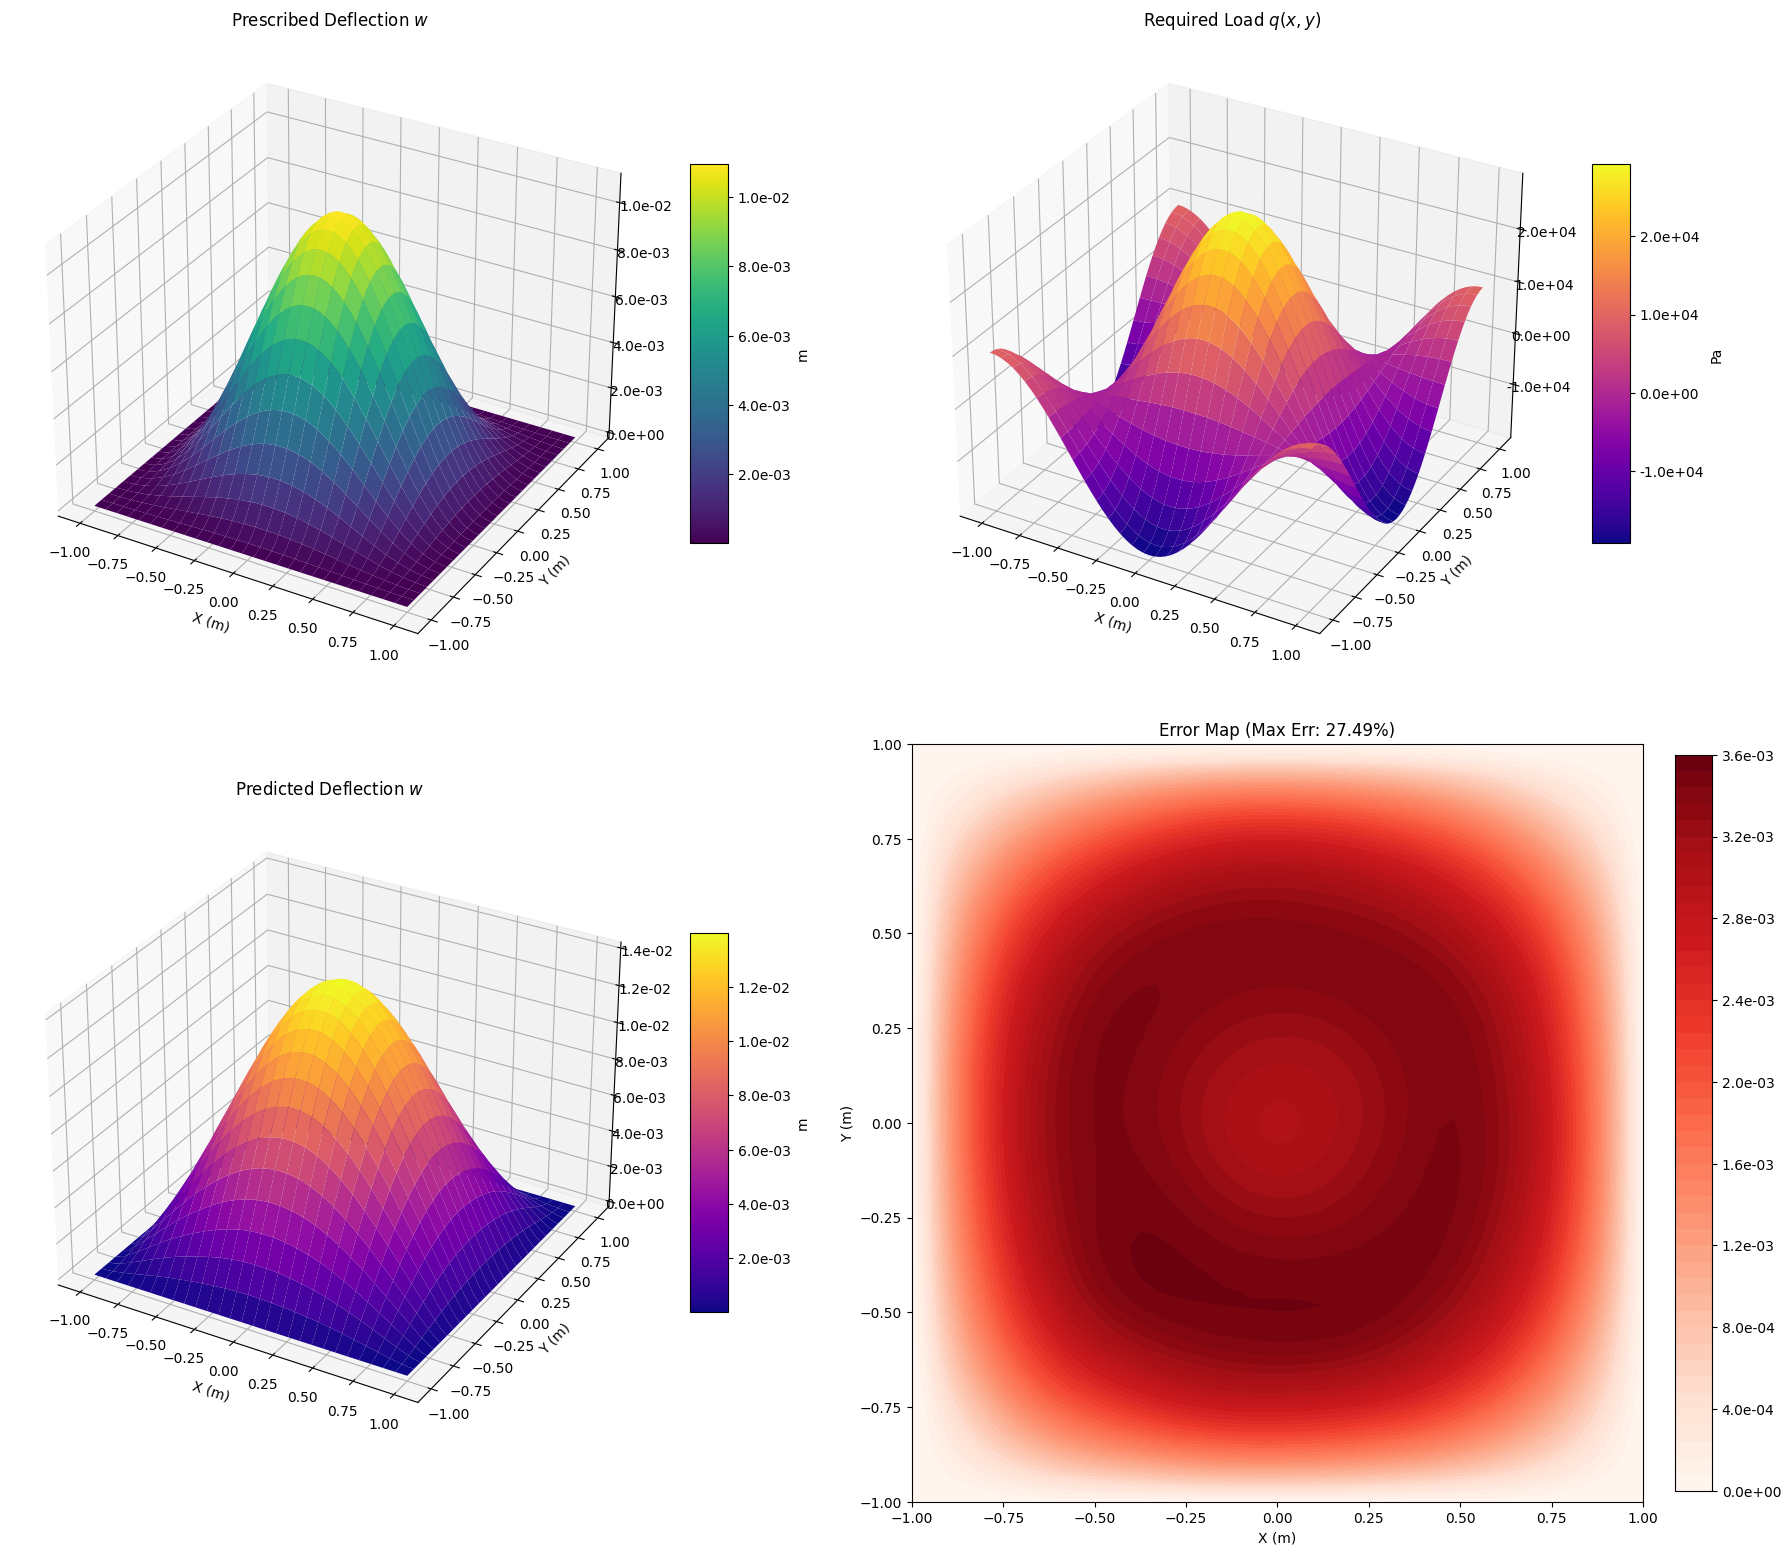

In [ ]:
# 3.2. Plotting the Prescribed Deflection and Required Load
X_np = X_grid.numpy()
Y_np = Y_grid.numpy()

fig = plt.figure(figsize=(18, 16))

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_np, Y_np, W_TRUE, cmap='viridis', edgecolor='none')
ax1.set_title("Prescribed Deflection $w$")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
# ax1.set_zlabel("Deflection (m)")
ax1.zaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='m', format='%.1e')

ax4 = fig.add_subplot(2, 2, 2, projection='3d')
surf4 = ax4.plot_surface(X_np, Y_np, Q_required, cmap='plasma', edgecolor='none')
ax4.set_title("Required Load $q(x,y)$")
ax4.set_xlabel("X (m)")
ax4.set_ylabel("Y (m)")
# ax4.set_zlabel("Load (Pa)")
ax4.zaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
fig.colorbar(surf4, ax=ax4, shrink=0.5, aspect=10, label='Pa', format='%.1e')

ax2 = fig.add_subplot(2, 2, 3, projection='3d')
surf2 = ax2.plot_surface(X_np, Y_np, W_PRED, cmap='plasma', edgecolor='none')
ax2.set_title("Predicted Deflection $w$")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
# ax2.set_zlabel("Deflection (m)")
ax2.zaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='m', format='%.1e')

ax3 = fig.add_subplot(2, 2, 4)
contour3 = ax3.contourf(X_np, Y_np, abs(W_PRED - W_TRUE), levels=50, cmap='Reds')
ax3.set_title(f"Error Map (Max Err: {error_percent:.2f}%)")
ax3.set_xlabel("X (m)")
ax3.set_ylabel("Y (m)")
fig.colorbar(contour3, ax=ax3, format='%.1e', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

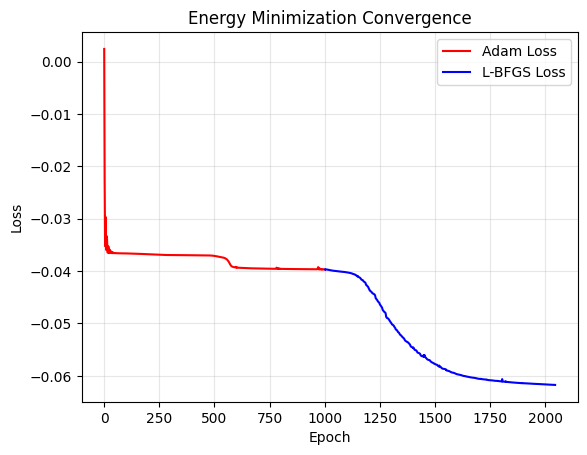

In [ ]:
# 3.3. Plotting Loss History
if len(loss_history) > Adam_epoch_len:
    plt.plot(
        range(Adam_epoch_len), 
        loss_history[:Adam_epoch_len], 
        color='red', 
        label='Adam Loss')
    plt.plot(
        range(Adam_epoch_len, len(loss_history)), 
        loss_history[Adam_epoch_len:], 
        color='blue', 
        label='L-BFGS Loss')
else:
    plt.plot(loss_history, color='black', label='Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Energy Minimization Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()